<a href="https://colab.research.google.com/github/rodrigopimentel12/aula-predicao/blob/main/notebooks/Modelagem_Preditiva_FGV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Modelagem Preditiva - FGV 2026

**Grupo:**
- João Victor Fortunato Teixeira Mundim (813190/2026)
- Martinho Aloisio Lenz (812869/2026)
- Nicolas Henrique Richardt da Silva (813138/2026)
- Renato Vargas Monteiro (812872/2026)
- Rodrigo Pimentel Carneiro (812440/2026)

---

## 📦 1. Configuração do Ambiente

In [1]:
# Instalar dependências (se necessário)
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl -q

In [2]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, LeaveOneOut, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


## 📥 2. Carregar Dados do Repositório

In [3]:
# Carregar dados diretamente do GitHub
url = 'https://github.com/rodrigopimentel12/aula-predicao/raw/main/dados/Dados%20de%20Treinamento.xlsx'
df = pd.read_excel(url)

print('✅ Dados carregados com sucesso!')
print(f'📊 Shape: {df.shape[0]} linhas x {df.shape[1]} colunas')

✅ Dados carregados com sucesso!
📊 Shape: 15 linhas x 6 colunas


In [4]:
# Visualizar os dados
df

,Idade,Renda_Mensal,Estado_Civil,Valor_Compras,Numero_Compras,Classe
0,22,2200.0,Casado,300,2,0
1,27,2800.0,Casado,450,3,0
2,31,3200.0,Casado,520,4,0
3,35,4500.0,Casado,700,5,0
4,39,5200.0,Casado,850,6,0
5,42,6100.0,Casado,1100,8,0
6,46,7500.0,Casado,1250,9,0
7,49,NaN,Solteiro,1400,10,1
8,52,9800.0,Casado,1700,12,1
9,55,11000.0,Casado,2100,14,1


## 📊 3. Análise Exploratória dos Dados (EDA)

In [5]:
# Informações gerais
print('=== INFORMAÇÕES DO DATASET ===')
print(f'\nColunas: {df.columns.tolist()}')
print(f'\nTipos de dados:')
print(df.dtypes)
print(f'\nValores ausentes:')
print(df.isnull().sum())

=== INFORMAÇÕES DO DATASET ===

Colunas: ['Idade', 'Renda_Mensal', 'Estado_Civil', 'Valor_Compras', 'Numero_Compras', 'Classe']

Tipos de dados:
Idade               int64
Renda_Mensal      float64
Estado_Civil       object
Valor_Compras       int64
Numero_Compras      int64
Classe              int64
dtype: object

Valores ausentes:
Idade             0
Renda_Mensal      2
Estado_Civil      0
Valor_Compras     0
Numero_Compras    0
Classe            0
dtype: int64


In [6]:
# Estatísticas descritivas
df.describe()

,Idade,Renda_Mensal,Valor_Compras,Numero_Compras,Classe
count,15.000000,13.000000,15.000000,15.000000,15.000000
mean,48.066667,10138.461538,1818.000000,12.066667,0.533333
std,15.266521,8127.682989,1304.416673,8.224238,0.516398
min,22.000000,2200.000000,300.000000,2.000000,0.000000
25%,37.000000,4500.000000,775.000000,5.500000,0.000000
50%,49.000000,7500.000000,1400.000000,10.000000,1.000000
75%,59.500000,13500.000000,2700.000000,17.000000,1.000000
max,72.000000,30000.000000,4500.000000,30.000000,1.000000


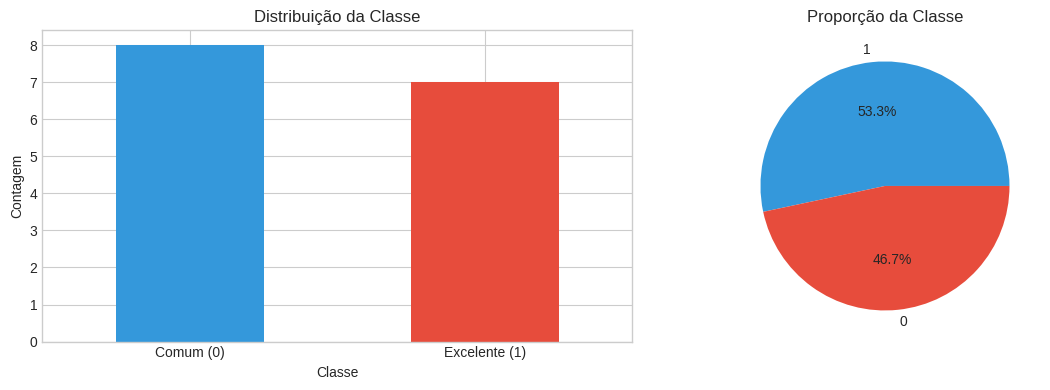

In [7]:
# Distribuição da variável alvo (Classe)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Contagem
df['Classe'].value_counts().plot(kind='bar', ax=ax[0], color=['#3498db', '#e74c3c'])
ax[0].set_title('Distribuição da Classe')
ax[0].set_xlabel('Classe')
ax[0].set_ylabel('Contagem')
ax[0].set_xticklabels(['Comum (0)', 'Excelente (1)'], rotation=0)

# Proporção
df['Classe'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%', colors=['#3498db', '#e74c3c'])
ax[1].set_title('Proporção da Classe')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

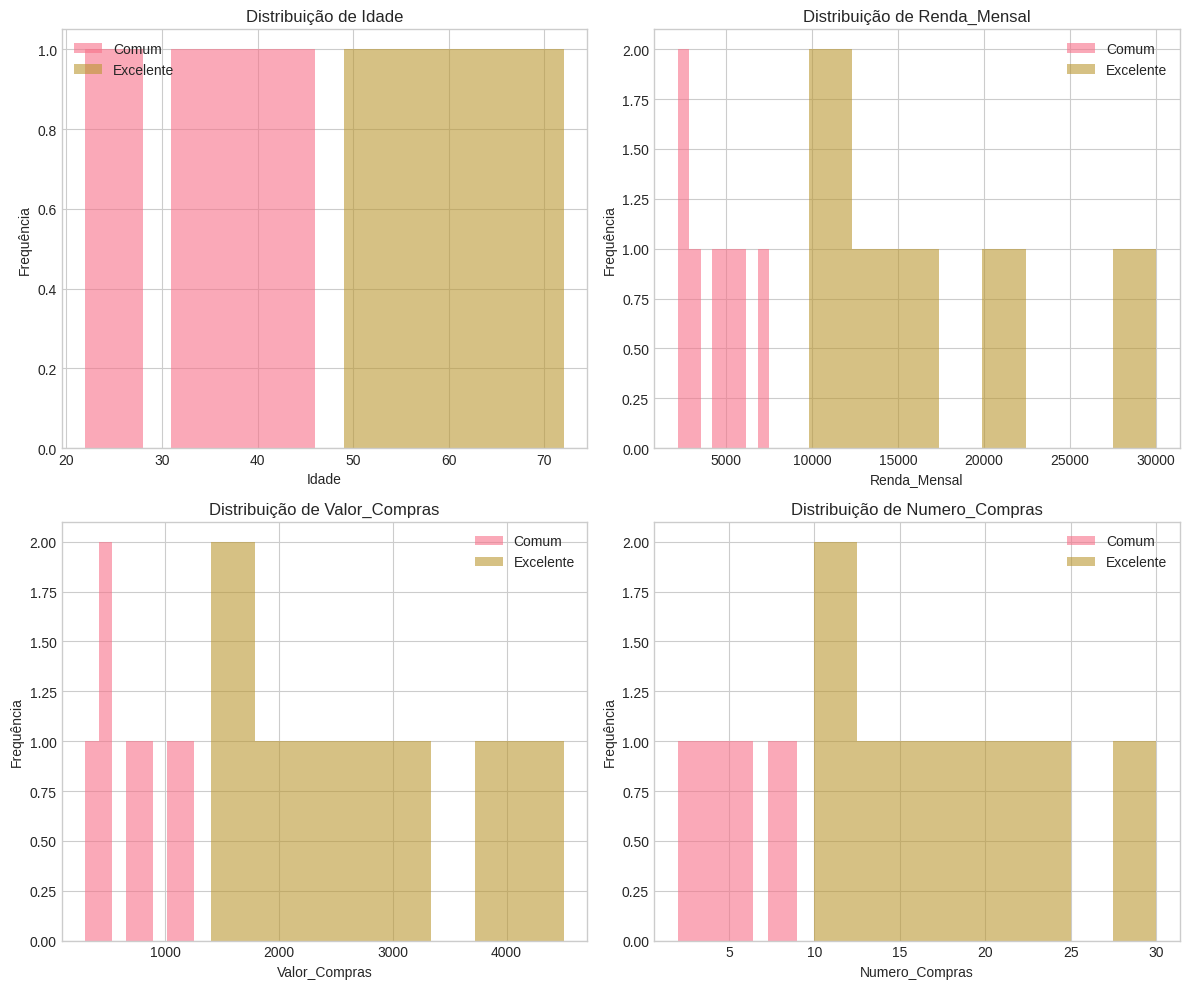

In [8]:
# Distribuição das variáveis numéricas
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

num_cols = ['Idade', 'Renda_Mensal', 'Valor_Compras', 'Numero_Compras']

for i, col in enumerate(num_cols):
    ax = axes[i//2, i%2]
    for classe in [0, 1]:
        data = df[df['Classe'] == classe][col].dropna()
        label = 'Comum' if classe == 0 else 'Excelente'
        ax.hist(data, alpha=0.6, label=label, bins=8)
    ax.set_title(f'Distribuição de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')
    ax.legend()

plt.tight_layout()
plt.show()

## 🔗 4. Análise de Correlação

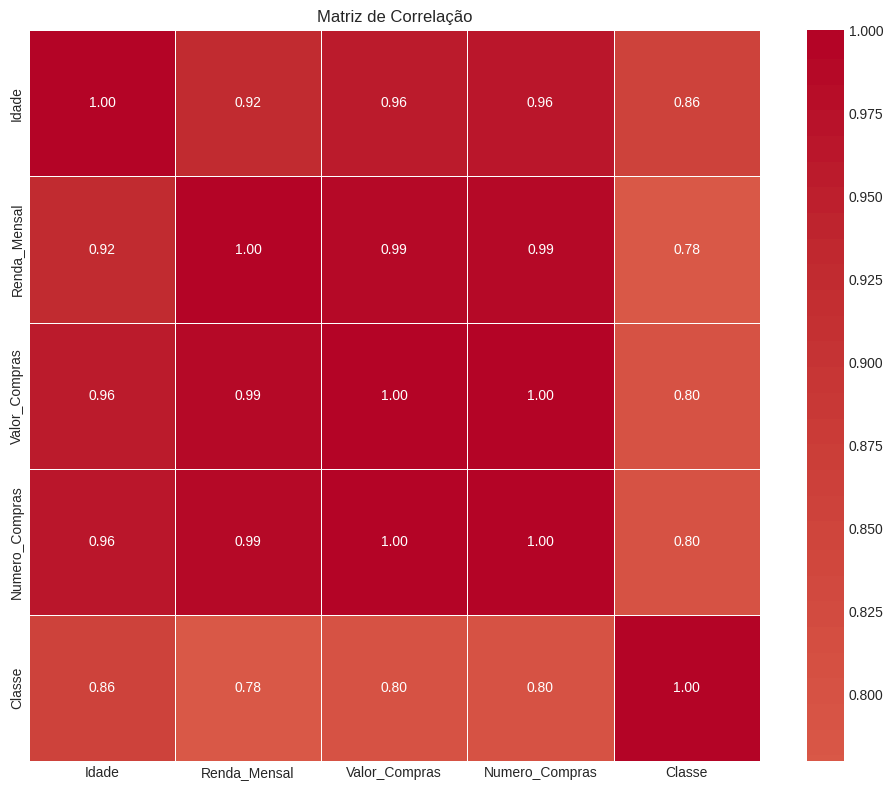

In [9]:
# Matriz de correlação
correlation_matrix = df[['Idade', 'Renda_Mensal', 'Valor_Compras', 'Numero_Compras', 'Classe']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

In [10]:
# Correlação com a variável alvo
print('=== CORRELAÇÃO COM A CLASSE ===')
correlacoes = correlation_matrix['Classe'].drop('Classe').sort_values(ascending=False)
print(correlacoes)

=== CORRELAÇÃO COM A CLASSE ===
Idade             0.855906
Valor_Compras     0.801241
Numero_Compras    0.798327
Renda_Mensal      0.779917
Name: Classe, dtype: float64


## 🛠️ 5. Feature Engineering (Engenharia de Variáveis)

Aplicando as técnicas do exercício.

### 5.1 Tratamento de Valores Ausentes

In [11]:
# Verificar valores ausentes
print('Valores ausentes antes do tratamento:')
print(df.isnull().sum())

# Criar cópia para tratamento
df_tratado = df.copy()

# Imputar pela mediana (evita viés de outliers)
mediana_renda = df_tratado['Renda_Mensal'].median()
df_tratado['Renda_Mensal'].fillna(mediana_renda, inplace=True)

print(f'\n✅ Valores ausentes imputados com a mediana: R$ {mediana_renda:,.2f}')
print('\nValores ausentes após tratamento:')
print(df_tratado.isnull().sum())

Valores ausentes antes do tratamento:
Idade             0
Renda_Mensal      2
Estado_Civil      0
Valor_Compras     0
Numero_Compras    0
Classe            0
dtype: int64

✅ Valores ausentes imputados com a mediana: R$ 7,500.00

Valores ausentes após tratamento:
Idade             0
Renda_Mensal      0
Estado_Civil      0
Valor_Compras     0
Numero_Compras    0
Classe            0
dtype: int64


### 5.2 Criação de Novas Variáveis

In [12]:
# Ticket Médio
df_tratado['Ticket_Medio'] = df_tratado['Valor_Compras'] / df_tratado['Numero_Compras']

# Faixas de Idade
df_tratado['Faixa_Idade'] = pd.cut(df_tratado['Idade'],
                                    bins=[0, 30, 50, 100],
                                    labels=['Jovem', 'Adulto', 'Senior'])

# Log da Renda (para normalizar distribuição)
df_tratado['Log_Renda'] = np.log(df_tratado['Renda_Mensal'])

print('✅ Novas variáveis criadas:')
print('- Ticket_Medio = Valor_Compras / Numero_Compras')
print('- Faixa_Idade = Categorização da idade')
print('- Log_Renda = Logaritmo da renda')

df_tratado.head()

✅ Novas variáveis criadas:
- Ticket_Medio = Valor_Compras / Numero_Compras
- Faixa_Idade = Categorização da idade
- Log_Renda = Logaritmo da renda


,Idade,Renda_Mensal,Estado_Civil,Valor_Compras,Numero_Compras,Classe,Ticket_Medio,Faixa_Idade,Log_Renda
0,22,2200.0,Casado,300,2,0,150.000000,Jovem,7.696213
1,27,2800.0,Casado,450,3,0,150.000000,Jovem,7.937375
2,31,3200.0,Casado,520,4,0,130.000000,Adulto,8.070906
3,35,4500.0,Casado,700,5,0,140.000000,Adulto,8.411833
4,39,5200.0,Casado,850,6,0,141.666667,Adulto,8.556414


### 5.3 One-Hot Encoding

In [13]:
# One-Hot Encoding para Estado_Civil (se mantido)
print('Estado_Civil - Distribuição:')
print(df_tratado['Estado_Civil'].value_counts())

# Criar dummies
df_encoded = pd.get_dummies(df_tratado, columns=['Estado_Civil', 'Faixa_Idade'], drop_first=True)
print('\n✅ One-Hot Encoding aplicado')
df_encoded.head()

Estado_Civil - Distribuição:
Estado_Civil
Casado      14
Solteiro     1
Name: count, dtype: int64

✅ One-Hot Encoding aplicado


,Idade,Renda_Mensal,Valor_Compras,Numero_Compras,Classe,Ticket_Medio,Log_Renda,Estado_Civil_Solteiro,Faixa_Idade_Adulto,Faixa_Idade_Senior
0,22,2200.0,300,2,0,150.000000,7.696213,False,False,False
1,27,2800.0,450,3,0,150.000000,7.937375,False,False,False
2,31,3200.0,520,4,0,130.000000,8.070906,False,True,False
3,35,4500.0,700,5,0,140.000000,8.411833,False,True,False
4,39,5200.0,850,6,0,141.666667,8.556414,False,True,False


## 🤖 6. Modelagem Preditiva

In [14]:
# Preparar features e target
feature_cols = ['Idade', 'Renda_Mensal', 'Valor_Compras', 'Numero_Compras', 'Ticket_Medio', 'Log_Renda']
X = df_encoded[feature_cols]
y = df_encoded['Classe']

# Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Features: {feature_cols}')
print(f'Shape X: {X_scaled.shape}')
print(f'Shape y: {y.shape}')

Features: ['Idade', 'Renda_Mensal', 'Valor_Compras', 'Numero_Compras', 'Ticket_Medio', 'Log_Renda']
Shape X: (15, 6)
Shape y: (15,)


In [15]:
# Testar múltiplos modelos com Leave-One-Out Cross-Validation
modelos = {
    'Regressão Logística': LogisticRegression(random_state=42),
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
}

loo = LeaveOneOut()
resultados = {}

print('=== RESULTADOS DOS MODELOS (Leave-One-Out CV) ===\n')

for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_scaled, y, cv=loo, scoring='accuracy')
    resultados[nome] = scores.mean()
    print(f'{nome}:')
    print(f'  Acurácia média: {scores.mean():.2%}')
    print(f'  Desvio padrão: {scores.std():.2%}')
    print()

=== RESULTADOS DOS MODELOS (Leave-One-Out CV) ===

Regressão Logística:
  Acurácia média: 93.33%
  Desvio padrão: 24.94%

Árvore de Decisão:
  Acurácia média: 93.33%
  Desvio padrão: 24.94%

Random Forest:
  Acurácia média: 86.67%
  Desvio padrão: 33.99%



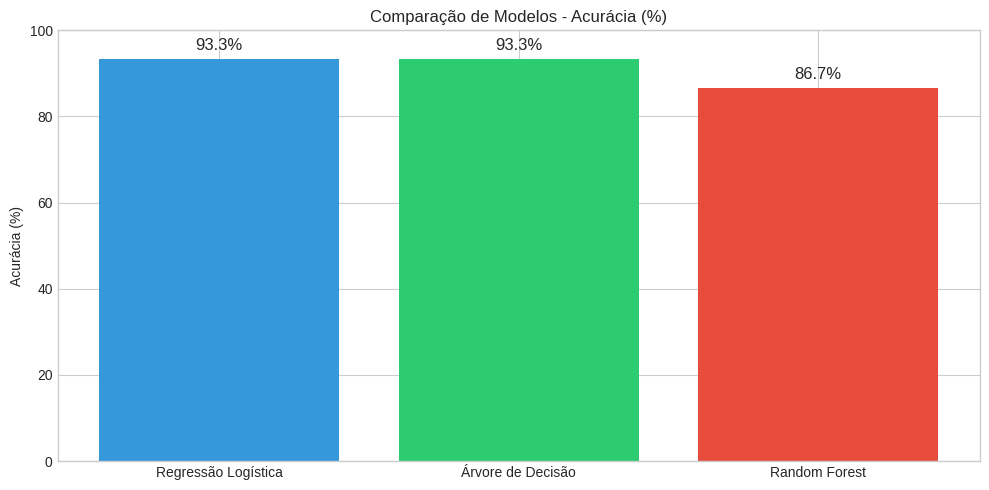

In [16]:
# Visualizar resultados
plt.figure(figsize=(10, 5))
plt.bar(resultados.keys(), [v*100 for v in resultados.values()], color=['#3498db', '#2ecc71', '#e74c3c'])
plt.title('Comparação de Modelos - Acurácia (%)')
plt.ylabel('Acurácia (%)')
plt.ylim(0, 100)
for i, (nome, acc) in enumerate(resultados.items()):
    plt.text(i, acc*100 + 2, f'{acc:.1%}', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

## 📈 7. Importância das Features

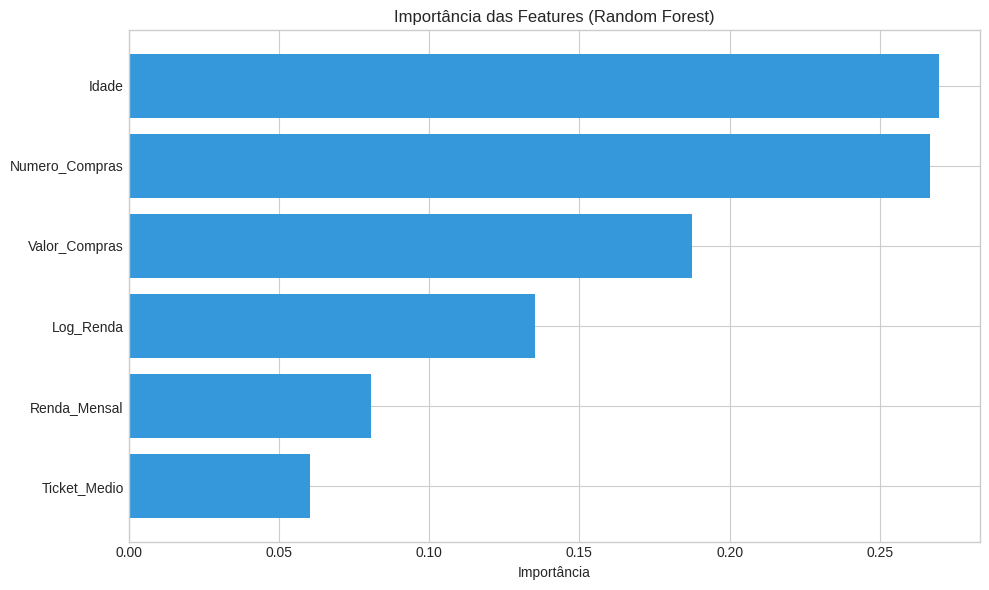

In [17]:
# Treinar Random Forest para ver importância
rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf.fit(X_scaled, y)

# Importância das features
importancia = pd.DataFrame({
    'Feature': feature_cols,
    'Importância': rf.feature_importances_
}).sort_values('Importância', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importancia['Feature'], importancia['Importância'], color='#3498db')
plt.xlabel('Importância')
plt.title('Importância das Features (Random Forest)')
plt.tight_layout()
plt.show()

## 📋 8. Resumo e Conclusões

In [18]:
print('='*60)
print('RESUMO DA ANÁLISE')
print('='*60)
print(f'''
📊 DATASET:
   - {len(df)} registros, {len(df.columns)} variáveis
   - Classe 0 (Comum): {len(df[df['Classe']==0])} ({len(df[df['Classe']==0])/len(df)*100:.1f}%)
   - Classe 1 (Excelente): {len(df[df['Classe']==1])} ({len(df[df['Classe']==1])/len(df)*100:.1f}%)

🛠️ FEATURE ENGINEERING:
   - Valores ausentes tratados com mediana
   - Criadas: Ticket_Medio, Faixa_Idade, Log_Renda
   - One-Hot Encoding aplicado

🤖 MELHOR MODELO: {max(resultados, key=resultados.get)}
   - Acurácia: {max(resultados.values()):.1%}

📈 FEATURES MAIS IMPORTANTES:
   - {importancia.iloc[-1]['Feature']}: {importancia.iloc[-1]['Importância']:.3f}
   - {importancia.iloc[-2]['Feature']}: {importancia.iloc[-2]['Importância']:.3f}
   - {importancia.iloc[-3]['Feature']}: {importancia.iloc[-3]['Importância']:.3f}
''')
print('='*60)

RESUMO DA ANÁLISE

📊 DATASET:
   - 15 registros, 6 variáveis
   - Classe 0 (Comum): 7 (46.7%)
   - Classe 1 (Excelente): 8 (53.3%)

🛠️ FEATURE ENGINEERING:
   - Valores ausentes tratados com mediana
   - Criadas: Ticket_Medio, Faixa_Idade, Log_Renda
   - One-Hot Encoding aplicado

🤖 MELHOR MODELO: Regressão Logística
   - Acurácia: 93.3%

📈 FEATURES MAIS IMPORTANTES:
   - Idade: 0.270
   - Numero_Compras: 0.267
   - Valor_Compras: 0.187



---

## 🔗 Links

- [Repositório GitHub](https://github.com/rodrigopimentel12/aula-predicao)
- [Análise da IA](https://github.com/rodrigopimentel12/aula-predicao/blob/main/ANALISE_IA.md)

---

*FGV 2026 - Modelagem Preditiva*